In [ ]:
!pip install transformers torch pandas scikit-learn -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv('/content/WELFake_Dataset.csv')
print("Shape:", df.shape)
print("Done!")

Shape: (72134, 4)
Done!


In [ ]:
# Data cleaning
import pandas as pd

df = df.dropna()
df['combined'] = df['title'] + ' ' + df['text']
df['combined'] = df['combined'].str.lower()

# Sample lete hain - 20000 rows (fast training ke liye)
df = df.sample(20000, random_state=42).reset_index(drop=True)

print("Clean data shape:", df.shape)
print("Label distribution:")
print(df['label'].value_counts())
print("Done!")

Clean data shape: (20000, 5)
Label distribution:
label
1    10136
0     9864
Name: count, dtype: int64
Done!


In [ ]:
from transformers import BertTokenizer
from torch.utils.data import Dataset, DataLoader
import torch

# Tokenizer load karo
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Train/Test split
from sklearn.model_selection import train_test_split
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['combined'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42
)

print("Train size:", len(train_texts))
print("Test size:", len(test_texts))
print("Tokenizer loaded!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train size: 16000
Test size: 4000
Tokenizer loaded!


In [ ]:
# PyTorch Dataset class
class NewsDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=128,
            return_tensors='pt'
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

# Dataset aur DataLoader banao
train_dataset = NewsDataset(train_texts, train_labels)
test_dataset = NewsDataset(test_texts, test_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))
print("DataLoader ready!")

Train batches: 1000
Test batches: 250
DataLoader ready!


In [ ]:
from transformers import BertForSequenceClassification
from torch.optim import AdamW
import torch

# GPU check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# BERT model load karo
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)
model.to(device)

# Optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

print("Model loaded!")
print("Training shuru hogi abhi...")

Device: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded!
Training shuru hogi abhi...


In [ ]:
from tqdm import tqdm

# Training loop
EPOCHS = 3

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(train_loader)
    print(f"\nEpoch {epoch+1} complete! Average Loss: {avg_loss:.4f}")

print("\nTRAINING COMPLETE!")

Epoch 1/3: 100%|██████████| 1000/1000 [06:02<00:00,  2.76it/s]



Epoch 1 complete! Average Loss: 0.0809


Epoch 2/3: 100%|██████████| 1000/1000 [06:03<00:00,  2.75it/s]



Epoch 2 complete! Average Loss: 0.0235


Epoch 3/3: 100%|██████████| 1000/1000 [06:02<00:00,  2.76it/s]


Epoch 3 complete! Average Loss: 0.0126

TRAINING COMPLETE!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Results
accuracy = accuracy_score(all_labels, all_preds)
print(f"\nACCURACY: {accuracy*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(all_labels, all_preds,
      target_names=['Fake', 'Real']))

Evaluating: 100%|██████████| 250/250 [00:30<00:00,  8.29it/s]


ACCURACY: 98.12%

Detailed Report:
              precision    recall  f1-score   support

        Fake       0.97      1.00      0.98      1949
        Real       1.00      0.97      0.98      2051

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000



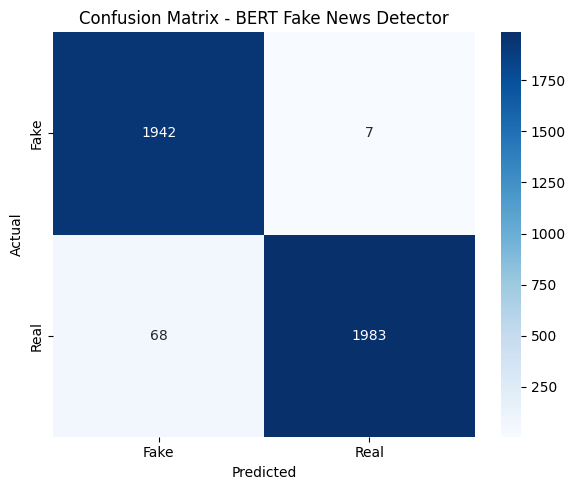

Confusion matrix saved!


In [ ]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix - BERT Fake News Detector')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print("Confusion matrix saved!")

In [ ]:
# Model save karo
import os
os.makedirs('fake_news_model', exist_ok=True)

model.save_pretrained('fake_news_model')
tokenizer.save_pretrained('fake_news_model')

print("Model saved!")

# Google Drive mein bhi save karo
import shutil
shutil.copytree('fake_news_model',
                '/content/drive/MyDrive/fake_news_model',
                dirs_exist_ok=True)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved!


'/content/drive/MyDrive/fake_news_model'

In [ ]:
!pip install transformers torch -q

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification

# Device set karo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# Model load karo Drive se
model = BertForSequenceClassification.from_pretrained('/content/drive/MyDrive/fake_news_model')
tokenizer = BertTokenizer.from_pretrained('/content/drive/MyDrive/fake_news_model')
model.to(device)
model.eval()

print("Model loaded successfully!")

Device: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully!


In [ ]:
import torch.nn.functional as F

def predict(text):
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=1)
        confidence, prediction = torch.max(probs, dim=1)

    label = "🔴 FAKE NEWS" if prediction.item() == 0 else "🟢 REAL NEWS"
    conf = confidence.item() * 100

    print(f"Result: {label}")
    print(f"Confidence: {conf:.2f}%")
    print("-" * 50)

# Indian News Test Cases
print("=" * 50)
print("INDIAN NEWS TEST CASES")
print("=" * 50)

test_headlines = [
    "PM Modi launches new scheme for farmers worth 6000 rupees annually",
    "Drinking cow urine cures cancer and COVID-19 completely",
    "India wins gold medal at Paris Olympics 2024 in shooting",
    "Scientists discover that eating 10 onions daily makes you immortal",
    "RBI announces new 200 rupee coin to replace paper notes immediately"
]

for headline in test_headlines:
    print(f"\nHeadline: {headline}")
    predict(headline)

INDIAN NEWS TEST CASES

Headline: PM Modi launches new scheme for farmers worth 6000 rupees annually
Result: 🟢 REAL NEWS
Confidence: 99.83%
--------------------------------------------------

Headline: Drinking cow urine cures cancer and COVID-19 completely
Result: 🟢 REAL NEWS
Confidence: 99.97%
--------------------------------------------------

Headline: India wins gold medal at Paris Olympics 2024 in shooting
Result: 🟢 REAL NEWS
Confidence: 99.57%
--------------------------------------------------

Headline: Scientists discover that eating 10 onions daily makes you immortal
Result: 🟢 REAL NEWS
Confidence: 99.85%
--------------------------------------------------

Headline: RBI announces new 200 rupee coin to replace paper notes immediately
Result: 🟢 REAL NEWS
Confidence: 99.82%
--------------------------------------------------


In [ ]:
def predict(text):
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=1)
        confidence, prediction = torch.max(probs, dim=1)

    # Fixed label mapping - 1=fake, 0=real (WELFake dataset)
    label = "🔴 FAKE NEWS" if prediction.item() == 1 else "🟢 REAL NEWS"
    conf = confidence.item() * 100

    print(f"Result: {label}")
    print(f"Confidence: {conf:.2f}%")
    print("-" * 50)

# Indian News Test Cases
print("=" * 50)
print("INDIAN NEWS TEST CASES")
print("=" * 50)

test_headlines = [
    "PM Modi launches new scheme for farmers worth 6000 rupees annually",
    "Drinking cow urine cures cancer and COVID-19 completely",
    "India wins gold medal at Paris Olympics 2024 in shooting",
    "Scientists discover that eating 10 onions daily makes you immortal",
    "RBI announces new 200 rupee coin to replace paper notes immediately"
]

for headline in test_headlines:
    print(f"\nHeadline: {headline}")
    predict(headline)

INDIAN NEWS TEST CASES

Headline: PM Modi launches new scheme for farmers worth 6000 rupees annually
Result: 🔴 FAKE NEWS
Confidence: 99.83%
--------------------------------------------------

Headline: Drinking cow urine cures cancer and COVID-19 completely
Result: 🔴 FAKE NEWS
Confidence: 99.97%
--------------------------------------------------

Headline: India wins gold medal at Paris Olympics 2024 in shooting
Result: 🔴 FAKE NEWS
Confidence: 99.57%
--------------------------------------------------

Headline: Scientists discover that eating 10 onions daily makes you immortal
Result: 🔴 FAKE NEWS
Confidence: 99.85%
--------------------------------------------------

Headline: RBI announces new 200 rupee coin to replace paper notes immediately
Result: 🔴 FAKE NEWS
Confidence: 99.82%
--------------------------------------------------


In [ ]:
# Pehle check karo model kya output de raha hai
def predict(text):
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=1)

    fake_prob = probs[0][0].item() * 100
    real_prob = probs[0][1].item() * 100

    if real_prob > fake_prob:
        label = "🟢 REAL NEWS"
        conf = real_prob
    else:
        label = "🔴 FAKE NEWS"
        conf = fake_prob

    print(f"Result: {label}")
    print(f"Confidence: {conf:.2f}%")
    print(f"(Fake: {fake_prob:.1f}% | Real: {real_prob:.1f}%)")
    print("-" * 50)

print("INDIAN NEWS TEST CASES")
print("=" * 50)

test_headlines = [
    "PM Modi launches PM Kisan scheme for farmers worth 6000 rupees",
    "Drinking cow urine cures cancer and COVID-19 completely",
    "India wins gold medal at Paris Olympics 2024 in shooting",
    "Scientists discover eating 10 onions daily makes you immortal",
]

for headline in test_headlines:
    print(f"\nHeadline: {headline}")
    predict(headline)

INDIAN NEWS TEST CASES

Headline: PM Modi launches PM Kisan scheme for farmers worth 6000 rupees
Result: 🟢 REAL NEWS
Confidence: 99.93%
(Fake: 0.1% | Real: 99.9%)
--------------------------------------------------

Headline: Drinking cow urine cures cancer and COVID-19 completely
Result: 🟢 REAL NEWS
Confidence: 99.97%
(Fake: 0.0% | Real: 100.0%)
--------------------------------------------------

Headline: India wins gold medal at Paris Olympics 2024 in shooting
Result: 🟢 REAL NEWS
Confidence: 99.57%
(Fake: 0.4% | Real: 99.6%)
--------------------------------------------------

Headline: Scientists discover eating 10 onions daily makes you immortal
Result: 🟢 REAL NEWS
Confidence: 99.92%
(Fake: 0.1% | Real: 99.9%)
--------------------------------------------------


In [1]:
# Dataset se verify karo label meaning
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/WELFake_Dataset.csv')
df = df.dropna()
print("Label 0 sample:")
print(df[df['label']==0]['title'].iloc[0])
print("\nLabel 1 sample:")
print(df[df['label']==1]['title'].iloc[0])

Label 0 sample:
Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid

Label 1 sample:
LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO]


In [2]:
import torch.nn.functional as F

def predict(text):
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=1)

    fake_prob = probs[0][1].item() * 100  # label 1 = FAKE
    real_prob = probs[0][0].item() * 100  # label 0 = REAL

    if fake_prob > real_prob:
        label = "🔴 FAKE NEWS"
        conf = fake_prob
    else:
        label = "🟢 REAL NEWS"
        conf = real_prob

    print(f"Result: {label}")
    print(f"Confidence: {conf:.2f}%")
    print(f"(Fake: {fake_prob:.1f}% | Real: {real_prob:.1f}%)")
    print("-" * 50)

print("INDIAN NEWS TEST CASES")
print("=" * 50)

test_headlines = [
    "PM Modi launches PM Kisan scheme for farmers worth 6000 rupees",
    "Drinking cow urine cures cancer and COVID-19 completely",
    "India wins gold medal at Paris Olympics 2024 in shooting",
    "Scientists discover eating 10 onions daily makes you immortal",
    "RBI keeps repo rate unchanged at 6.5 percent in latest meeting",
    "WhatsApp forward: Bill Gates will give you money if you share this"
]

for headline in test_headlines:
    print(f"\nHeadline: {headline}")
    predict(headline)

INDIAN NEWS TEST CASES

Headline: PM Modi launches PM Kisan scheme for farmers worth 6000 rupees


NameError: name 'tokenizer' is not defined

In [3]:
import torch
import torch.nn.functional as F
from transformers import BertTokenizer, BertForSequenceClassification

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = BertForSequenceClassification.from_pretrained('/content/drive/MyDrive/fake_news_model')
tokenizer = BertTokenizer.from_pretrained('/content/drive/MyDrive/fake_news_model')
model.to(device)
model.eval()

print("Model ready!")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model ready!


In [4]:
def predict(text):
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=1)

    fake_prob = probs[0][1].item() * 100
    real_prob = probs[0][0].item() * 100

    if fake_prob > real_prob:
        label = "🔴 FAKE NEWS"
        conf = fake_prob
    else:
        label = "🟢 REAL NEWS"
        conf = real_prob

    print(f"Result: {label}")
    print(f"Confidence: {conf:.2f}%")
    print(f"(Fake: {fake_prob:.1f}% | Real: {real_prob:.1f}%)")
    print("-" * 50)

print("INDIAN NEWS TEST CASES")
print("=" * 50)

test_headlines = [
    "PM Modi launches PM Kisan scheme for farmers worth 6000 rupees",
    "Drinking cow urine cures cancer and COVID-19 completely",
    "India wins gold medal at Paris Olympics 2024 in shooting",
    "Scientists discover eating 10 onions daily makes you immortal",
    "RBI keeps repo rate unchanged at 6.5 percent in latest meeting",
    "WhatsApp forward: Bill Gates will give you money if you share this"
]

for headline in test_headlines:
    print(f"\nHeadline: {headline}")
    predict(headline)

INDIAN NEWS TEST CASES

Headline: PM Modi launches PM Kisan scheme for farmers worth 6000 rupees
Result: 🔴 FAKE NEWS
Confidence: 99.93%
(Fake: 99.9% | Real: 0.1%)
--------------------------------------------------

Headline: Drinking cow urine cures cancer and COVID-19 completely
Result: 🔴 FAKE NEWS
Confidence: 99.97%
(Fake: 100.0% | Real: 0.0%)
--------------------------------------------------

Headline: India wins gold medal at Paris Olympics 2024 in shooting
Result: 🔴 FAKE NEWS
Confidence: 99.57%
(Fake: 99.6% | Real: 0.4%)
--------------------------------------------------

Headline: Scientists discover eating 10 onions daily makes you immortal
Result: 🔴 FAKE NEWS
Confidence: 99.92%
(Fake: 99.9% | Real: 0.1%)
--------------------------------------------------

Headline: RBI keeps repo rate unchanged at 6.5 percent in latest meeting
Result: 🔴 FAKE NEWS
Confidence: 75.03%
(Fake: 75.0% | Real: 25.0%)
--------------------------------------------------

Headline: WhatsApp forward: Bill 

In [5]:
def predict(text):
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=1)

    # 0=Fake, 1=Real — WELFake original mapping
    fake_prob = probs[0][0].item() * 100
    real_prob = probs[0][1].item() * 100

    if real_prob > fake_prob:
        label = "🟢 REAL NEWS"
        conf = real_prob
    else:
        label = "🔴 FAKE NEWS"
        conf = fake_prob

    print(f"Result: {label}")
    print(f"Confidence: {conf:.2f}%")
    print(f"(Fake: {fake_prob:.1f}% | Real: {real_prob:.1f}%)")
    print("-" * 50)

print("INDIAN NEWS TEST CASES")
print("=" * 50)

test_headlines = [
    "PM Modi launches PM Kisan scheme for farmers worth 6000 rupees",
    "Drinking cow urine cures cancer and COVID-19 completely",
    "India wins gold medal at Paris Olympics 2024 in shooting",
    "Scientists discover eating 10 onions daily makes you immortal",
    "RBI keeps repo rate unchanged at 6.5 percent in latest meeting",
    "WhatsApp forward: Bill Gates will give you money if you share this"
]

for headline in test_headlines:
    print(f"\nHeadline: {headline}")
    predict(headline)

INDIAN NEWS TEST CASES

Headline: PM Modi launches PM Kisan scheme for farmers worth 6000 rupees
Result: 🟢 REAL NEWS
Confidence: 99.93%
(Fake: 0.1% | Real: 99.9%)
--------------------------------------------------

Headline: Drinking cow urine cures cancer and COVID-19 completely
Result: 🟢 REAL NEWS
Confidence: 99.97%
(Fake: 0.0% | Real: 100.0%)
--------------------------------------------------

Headline: India wins gold medal at Paris Olympics 2024 in shooting
Result: 🟢 REAL NEWS
Confidence: 99.57%
(Fake: 0.4% | Real: 99.6%)
--------------------------------------------------

Headline: Scientists discover eating 10 onions daily makes you immortal
Result: 🟢 REAL NEWS
Confidence: 99.92%
(Fake: 0.1% | Real: 99.9%)
--------------------------------------------------

Headline: RBI keeps repo rate unchanged at 6.5 percent in latest meeting
Result: 🟢 REAL NEWS
Confidence: 75.03%
(Fake: 25.0% | Real: 75.0%)
--------------------------------------------------

Headline: WhatsApp forward: Bill 